#Importar librerías

In [ ]:
# Libreria para importar directamente desde Kaggle
import kagglehub

# Librerías para el manejo de datos
import pandas as pd
import numpy as np

# Librerías para creación de gráficos
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# Librerías para pruebas estadísticas
from scipy import stats as st
import math as mt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

# Librería para division test y train
from sklearn.model_selection import train_test_split

# Extra: acceso a comandos del Sistema Operativo
import os

#Selección del dataset

##Importamos de kaggle

In [ ]:
# Descargamos la versión más reciente del dataset desde Kaggle
path = kagglehub.dataset_download("price438/air-quality-dataset")

print("Ruta de descarga del dataset:", path)

# Construimos la ruta completa al archivo y creamos el DataFrame
# Ahora usamos el nombre de archivo correcto que encontramos al listar el directorio
df = pd.read_csv(os.path.join(path, "air_quality_dataset.csv"))

# Inspeccionamos la estructura de los datos
df.head()

100%|██████████| 136k/136k [00:00<00:00, 15.0MB/s]

Extracting files...
Ruta de descarga del dataset: /root/.cache/kagglehub/datasets/price438/air-quality-dataset/versions/1


,Date,City,AQI,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
0,2024-10-16,Los Angeles,128.0,28.78,68.84,58.29,57.56,2.781,17.10,3.4,82.2
1,2023-01-26,Jacksonville,111.0,28.73,61.93,59.00,35.73,1.810,16.33,17.0,36.0
2,2023-10-09,Houston,91.0,20.04,47.10,66.20,43.91,2.566,15.27,1.0,68.6
3,2023-08-17,Chicago,108.0,23.39,47.90,62.85,48.89,2.332,18.49,9.4,85.7
4,2023-04-15,Austin,106.0,26.51,56.08,62.38,NaN,1.867,15.93,17.3,48.7


##Información del dataset

**Sobre el dataset**

Este dataset recopila mediciones de calidad del aire provenientes de OpenAQ, AQICN y la EPA de Estados Unidos. Incluye una amplia colección de concentraciones de contaminantes, como PM2.5, PM10, NO₂, SO₂, CO y O₃. También proporciona valores del Índice de Calidad del Aire (AQI) y condiciones meteorológicas relevantes. El dataset refleja situaciones del mundo real, ya que contiene valores faltantes, outliers (valores atípicos) y duplicados. Esto lo hace ideal para practicar el preprocesamiento de datos, la limpieza y la ingeniería de variables (features).

Gracias a la diversidad de sus variables, este dataset permite abordar tareas de machine learning como regresión, clasificación y pronóstico. También es útil para análisis exploratorio de datos (EDA) y proyectos de visualización que estudien cómo varían los niveles de contaminación a lo largo del tiempo y entre distintas regiones. Investigadores, estudiantes y entusiastas de datos pueden usarlo para construir modelos predictivos, analizar patrones de contaminación y probar flujos de trabajo de ciencia de datos aplicada al medio ambiente.

**Diccionario de datos:**

*   AQI (Air Quality Index): Índice de calidad del Aire **(posible variable target)**
*   PM2.5 (Particulate Matter 2.5): Microparticulas contaminantes que se encuentran en el aire y cuyo diámetro es menor a 2.5 micrómetros. Son respirables por lo que pueden llegar a los pulmones o torrente sanguíneo.
*   PM10 (Particulate Matter 10): Partículas sólidas o líquidas y cuyo diámetro es de 10 micrómetros o menos. Ejemplo polvo, polen o cenizas.
*   Ozone (O₃): El ozono es un gas compuesto por tres átomos de oxígeno que actúa como un escudo protector vital para la vida en la Tierra o como un contaminante nocivo para la salud humana.
*   NO2 (Nitrogen Dioxide): El dióxido de nitrógeno es un gas tóxico y contaminante atmosférico. Se produce principalmente por la quema de combustibles fósiles en el transporte y la industria, y afecta directamente la salud humana al irritar las vías respiratorias.
*   CO (Carbon Monoxide): El monóxido de carbono es un gas altamente tóxico, incoloro, inodoro e insípido. Se produce por la combustión incompleta de materiales como gas, leña, carbón o nafta, cuando no hay suficiente oxígeno.
*   SO2 (Sulfur Dioxide): El dióxido de azufre es un gas incoloro, no inflamable y altamente irritante con un olor penetrante. Es un contaminante atmosférico primario formado principalmente por la quema de combustibles fósiles (carbón y petróleo) y las emisiones volcánicas.











**Referencias numéricas de los datos:**

* AQI (Air Quality Index): Valores: De 0 a 500. Significado: 0 - 100 es aire seguro/aceptable. Mayor a 150 ya es dañino para la población general; valores cercanos a 500 representan emergencias ambientales.

* PM2.5 (Particulate Matter 2.5): Valores: De 0 a más de 250 µg/m³. Significado: Valores bajos indican aire limpio. Valores altos significan alta concentración de partículas peligrosas.

* PM10 (Particulate Matter 10): Valores: De 0 a más de 400 µg/m³. Significado: Valores altos indican ambientes polvorientos o presencia de hollín grueso.

* Ozone ($O_3$): Valores: De 0 a más de 200 ppb (partes por billón). Significado: Tiende a subir en días calurosos de verano. Valores altos causan irritación pulmonar y tos.

* NO2 (Nitrogen Dioxide): Valores: De 0 a más de 200 ppb. Significado: Valores altos disparan ataques de asma y problemas respiratorios.

* CO (Carbon Monoxide): Valores: De 0 a más de 50 ppm (partes por millón). Significado: Valores altos indican zonas de tráfico muy congestionado o encerrado.

* SO2 (Sulfur Dioxide): Valores: De 0 a más de 100 ppb. Significado: Valores altos causan fuerte irritación en ojos y garganta y es el precursor de la lluvia ácida.

#Análisis exploratorio inicial (EDA)

##Datos generales

In [ ]:
# Información general del dataset (nombres de columnas y tipos de datos)
print("\nInformación general del dataset\n")
df.info()
print()
print("-"*60)

# Verificamos cuántos valores nulos hay por cada columna
print("\nCantidad de valores nulos por columna\n")
print(df.isnull().sum())
print()
print("-"*60)

# Consultamos la cantidad total de filas y columnas (forma del DataFrame)
print("\nCantidad total de filas y columnas\n")
print(df.shape)


Información general del dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5583 entries, 0 to 5582
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         5583 non-null   object 
 1   City         5583 non-null   object 
 2   AQI          5472 non-null   float64
 3   PM2.5        5486 non-null   float64
 4   PM10         5523 non-null   float64
 5   Ozone        5508 non-null   float64
 6   NO2          5490 non-null   float64
 7   CO           5421 non-null   float64
 8   SO2          5454 non-null   float64
 9   Temperature  5435 non-null   float64
 10  Humidity     5479 non-null   float64
dtypes: float64(9), object(2)
memory usage: 479.9+ KB

------------------------------------------------------------

Cantidad de valores nulos por columna

Date             0
City             0
AQI            111
PM2.5           97
PM10            60
Ozone           75
NO2             93
CO             162
SO2  

Hay nulos en los campos:

* AQI            111
* PM2.5           97
* PM10            60
* Ozone           75
* NO2             93
* CO             162
* SO2            129
* Temperature    148
* Humidity       104

Por lo que la decisión es eliminar los registros con AQI nulo (ya que será la variable a predecir) e imputar el resto de las variables.

In [ ]:
# Primer vistazo al dataset
print("\nPrimeras 5 filas del dataset:")
display(df.head())



Primeras 5 filas del dataset:


,Date,City,AQI,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
0,2024-10-16,Los Angeles,128.0,28.78,68.84,58.29,57.56,2.781,17.10,3.4,82.2
1,2023-01-26,Jacksonville,111.0,28.73,61.93,59.00,35.73,1.810,16.33,17.0,36.0
2,2023-10-09,Houston,91.0,20.04,47.10,66.20,43.91,2.566,15.27,1.0,68.6
3,2023-08-17,Chicago,108.0,23.39,47.90,62.85,48.89,2.332,18.49,9.4,85.7
4,2023-04-15,Austin,106.0,26.51,56.08,62.38,NaN,1.867,15.93,17.3,48.7


In [ ]:
print("\nDimensiones del dataset (filas, columnas):")
print(df.shape)


Dimensiones del dataset (filas, columnas):
(5583, 11)


In [ ]:
print("\nResumen estadístico de las variables numéricas:")
display(df.describe())


Resumen estadístico de las variables numéricas:


,AQI,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
count,5472.000000,5486.000000,5523.000000,5508.000000,5490.000000,5421.000000,5454.000000,5435.000000,5479.000000
mean,111.969664,26.271325,56.925913,65.779486,43.071980,2.167954,15.829078,14.848556,60.338876
std,24.152583,11.771521,15.619230,16.065461,11.077596,1.027549,8.490650,11.801714,21.586163
min,46.000000,9.210000,20.490000,28.350000,22.390000,0.722000,0.000000,-19.700000,8.600000
25%,96.000000,22.670000,48.320000,54.330000,38.150000,1.849000,12.970000,5.000000,42.600000
50%,110.000000,25.630000,55.890000,62.990000,42.640000,2.134000,15.550000,14.600000,60.800000
75%,126.000000,29.070000,64.590000,75.252500,47.270000,2.424000,18.197500,24.800000,78.700000
max,497.000000,461.330000,448.640000,283.970000,400.990000,47.281000,290.760000,53.500000,100.000000


In [ ]:
print("\nNombres de las columnas:")
display(df.columns)


Nombres de las columnas:


Index(['Date', 'City', 'AQI', 'PM2.5', 'PM10', 'Ozone', 'NO2', 'CO', 'SO2',
       'Temperature', 'Humidity'],
      dtype='object')

In [ ]:
print("\nColumnas numéricas:")
display(df.select_dtypes(include="number").columns)

print("\nColumnas no numéricas:")
display(df.select_dtypes(exclude="number").columns)


Columnas numéricas:


Index(['AQI', 'PM2.5', 'PM10', 'Ozone', 'NO2', 'CO', 'SO2', 'Temperature',
       'Humidity'],
      dtype='object')


Columnas no numéricas:


Index(['Date', 'City'], dtype='object')

In [ ]:
print(df['City'].unique())

['Los Angeles' 'Jacksonville' 'Houston' 'Chicago' 'Austin' 'San Antonio'
 'New York' 'Dallas' 'San Diego' 'Phoenix' 'Fort Worth' 'Philadelphia'
 'San Jose' 'Charlotte' 'Columbus']


In [ ]:
# Definimos tus columnas numéricas
cols_numericas = [
    'AQI', 'PM2.5', 'PM10', 'Ozone', 'NO2', 'CO', 'SO2', 'Temperature',
       'Humidity'
]

# Obtenemos min y max
min_max_df = df[cols_numericas].agg(['min', 'max']).T
print("Límites de las variables numéricas:")
print(min_max_df)

Límites de las variables numéricas:
                min      max
AQI          46.000  497.000
PM2.5         9.210  461.330
PM10         20.490  448.640
Ozone        28.350  283.970
NO2          22.390  400.990
CO            0.722   47.281
SO2           0.000  290.760
Temperature -19.700   53.500
Humidity      8.600  100.000


In [ ]:
print("\nLos 10 valores más frecuentes de la columna 'City':")
display(df["City"].value_counts().head(10))


Los 10 valores más frecuentes de la columna 'City':


,count
City,
San Diego,391
Jacksonville,389
Los Angeles,389
San Antonio,386
Austin,383
San Jose,381
Fort Worth,375
Columbus,374
Houston,365


##Visualizaciones

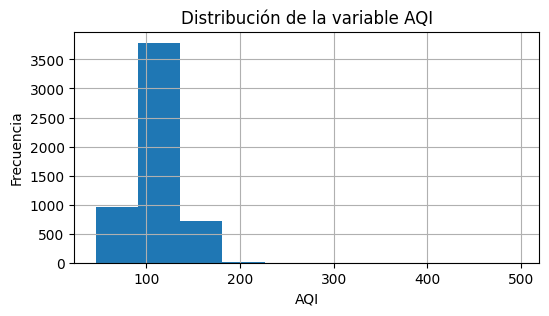

In [ ]:
# HISTOGRAMA: Distribución de AQI
plt.figure(figsize=(6, 3))
df["AQI"].hist(bins=10)
plt.title("Distribución de la variable AQI")
plt.xlabel("AQI")
plt.ylabel("Frecuencia")
plt.show()

El histograma muestra que la mayoría de los registros presentan valores de AQI cercanos a 100, mientras que los valores extremadamente altos son poco frecuentes. La distribución presenta asimetría positiva, lo que indica que existen pocos episodios de contaminación muy elevada en comparación con la mayoría de las observaciones.

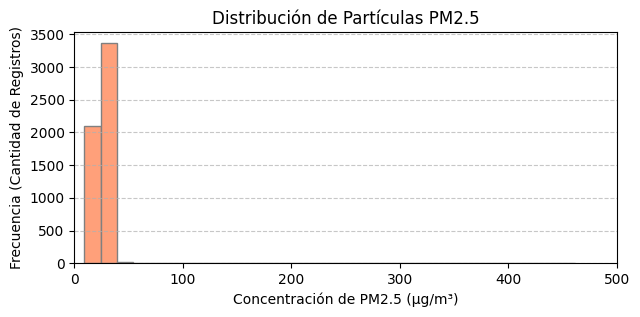

In [ ]:
# HISTOGRAMA: Distribución de PM2.5
plt.figure(figsize=(7, 3))

# Usamos PM2.5 sin NULOS
plt.hist(df['PM2.5'].dropna(), bins=30, color='lightsalmon', edgecolor='grey')

plt.title('Distribución de Partículas PM2.5')
plt.xlabel('Concentración de PM2.5 (µg/m³)')
plt.ylabel('Frecuencia (Cantidad de Registros)')

# Máximo 461
plt.xlim(0, 500)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

El histograma muestra que la concentración de PM2.5 se concentra principalmente en valores bajos y moderados, mientras que existen pocos registros con concentraciones extremadamente altas. También sucede que tiene algunos registros más elevados pero poco frecuentes.

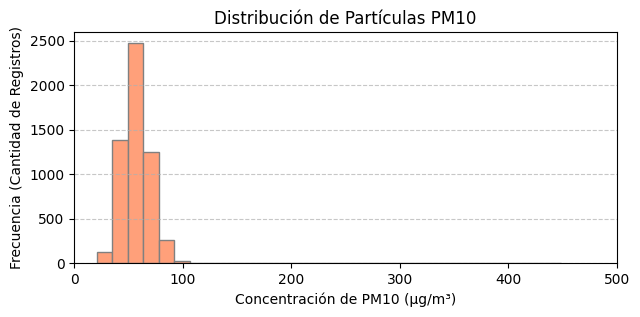

In [ ]:
# HISTOGRAMA: Distribución de PM10
plt.figure(figsize=(7, 3))

# Usamos PM10 sin NULOS
plt.hist(df['PM10'].dropna(), bins=30, color='lightsalmon', edgecolor='grey')

plt.title('Distribución de Partículas PM10')
plt.xlabel('Concentración de PM10 (µg/m³)')
plt.ylabel('Frecuencia (Cantidad de Registros)')

# Máximo 448
plt.xlim(0, 500)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

La distribución de PM10 está concentrada principalmente entre 40 y 70 μg/m³. Presenta una ligera asimetría positiva debido a la existencia de pocos registros con concentraciones muy elevadas.

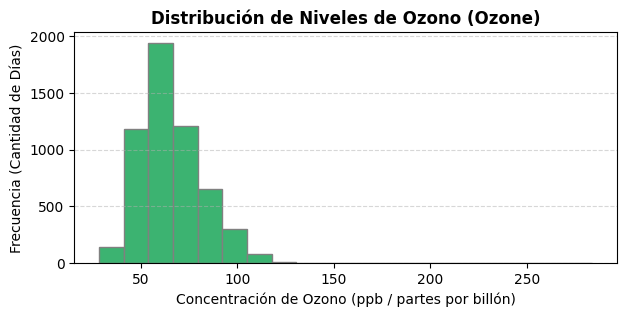

In [ ]:
# HISTOGRAMA: Distribución de los niveles de Ozono
plt.figure(figsize=(7, 3))

# Usamos 'Ozone' sin nulos
plt.hist(df['Ozone'].dropna(), bins=20, color='mediumseagreen', edgecolor='grey')

plt.title('Distribución de Niveles de Ozono (Ozone)', fontsize=12, fontweight='bold')
plt.xlabel('Concentración de Ozono (ppb / partes por billón)')
plt.ylabel('Frecuencia (Cantidad de Días)')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

La concentración de ozono presenta con la mayoría de los registros concentrados entre 45 y 85 ppb y un máximo de frecuencia alrededor de 60-70 ppb. La distribución muestra una ligera asimetría positiva debido a la presencia de algunos valores elevados, aunque estos representan una pequeña proporción del conjunto de datos.

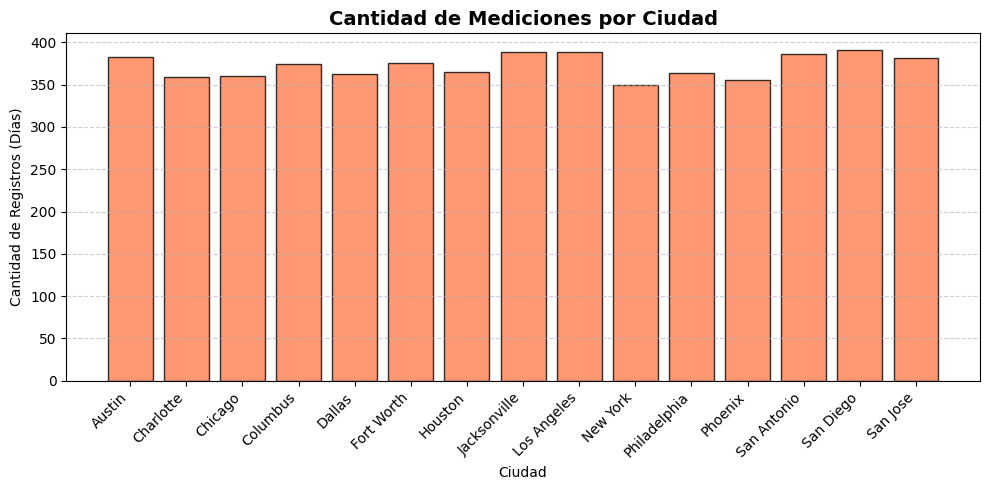

In [ ]:
# GRÁFICO DE BARRAS: Distribución de Mediciones por Ciudad

# Contamos los registros por ciudad y los ordenamos alfabéticamente
cat_counts = df['City'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(cat_counts.index, cat_counts.values, color='coral', edgecolor='black', alpha=0.8)

plt.title('Cantidad de Mediciones por Ciudad', fontsize=14, fontweight='bold')
plt.xlabel('Ciudad')
plt.ylabel('Cantidad de Registros (Días)')

# Rotamos las etiquetas 45 grados obligatoriamente para que los nombres no se pisen
# ha='right' alinea el texto al borde de la barra de forma prolija
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.6)

# tight_layout evita que los nombres de las ciudades se corten abajo de la imagen
plt.tight_layout()
plt.show()

El gráfico muestra que el dataset contiene una cantidad de mediciones relativamente uniforme para todas las ciudades analizadas, con valores que oscilan aproximadamente entre 350 y 390 registros. Esto indica que la variable Ciudad está bien representada y que no existen desbalances importantes en el número de observaciones por ubicación.

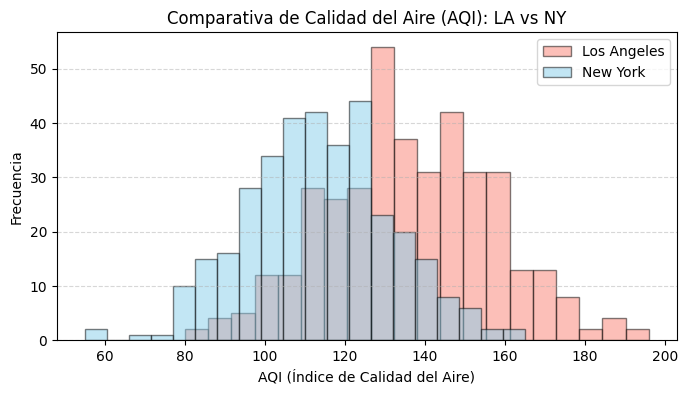

In [ ]:
# HISTOGRAMA COMPARATIVO: AQI entre Los Angeles y New York
plt.figure(figsize=(8, 4))

aqi_la = df[df['City'] == 'Los Angeles']['AQI'].dropna()
aqi_ny = df[df['City'] == 'New York']['AQI'].dropna()

#histogramas superpuestos
plt.hist(aqi_la, bins=20, alpha=0.5, label='Los Angeles', color='salmon', edgecolor='black')
plt.hist(aqi_ny, bins=20, alpha=0.5, label='New York', color='skyblue', edgecolor='black')

plt.title('Comparativa de Calidad del Aire (AQI): LA vs NY')
plt.xlabel('AQI (Índice de Calidad del Aire)')
plt.ylabel('Frecuencia')
plt.legend(loc='upper right')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

 Este gráfico permite contrastar el comportamiento de la variable objetivo (AQI) entre las dos principales ciudades del dataset. Evidencia visualmente que Nueva York tiende a mantener una mejor calidad del aire (con una distribución desplazada hacia valores menores), mientras que Los Ángeles presenta una mayor frecuencia de niveles críticos y un sesgo hacia la derecha, justificando la inclusión de la localización como una variable predictora clave para los modelos.

/tmp/ipykernel_1829/2886994328.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


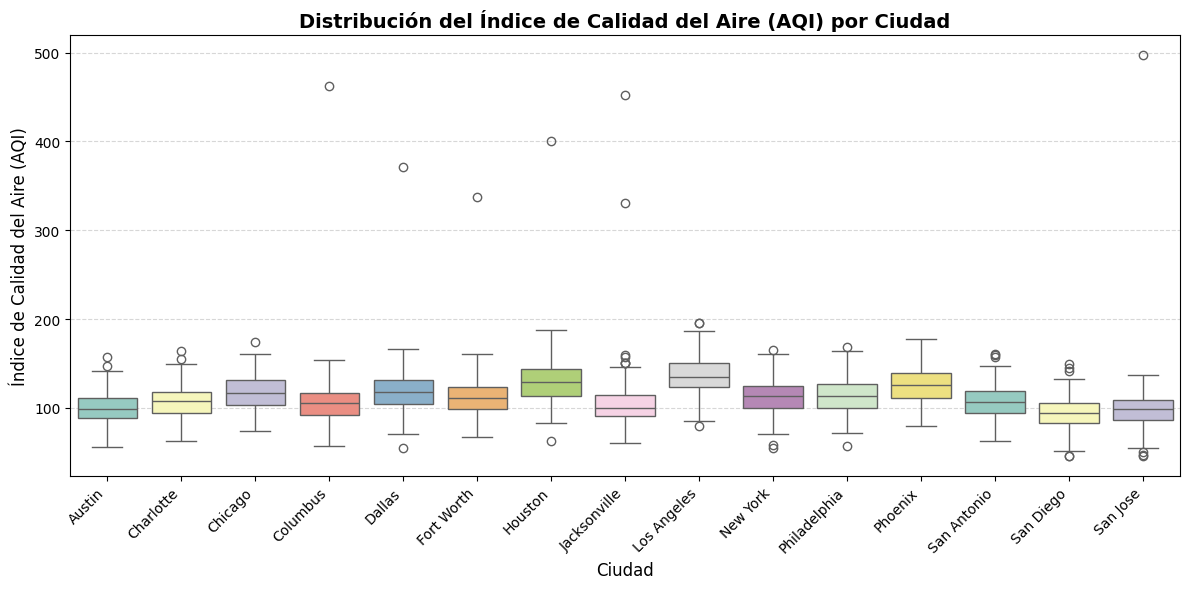

In [ ]:
# BOXPLOT: Distribución del AQI por Ciudad
plt.figure(figsize=(12, 6))

# Eliminamos nulos de AQI
df_filtrado = df.dropna(subset=['AQI'])

# Creamos el boxplot ordenando las ciudades alfabéticamente para mayor prolijidad
sns.boxplot(
    x='City',
    y='AQI',
    data=df_filtrado,
    order=sorted(df_filtrado['City'].unique()),
    palette='Set3'
)

plt.title('Distribución del Índice de Calidad del Aire (AQI) por Ciudad', fontsize=14, fontweight='bold')
plt.xlabel('Ciudad', fontsize=12)
plt.ylabel('Índice de Calidad del Aire (AQI)', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Este gráfico expone la variabilidad y dispersión de la calidad del aire entre las distintas ciudades del dataset. Revela que, si bien la mayoría comparte una mediana similar (entre 90 y 130 de AQI), ciudades como Columbus, Jacksonville, Houston y San Jose registran valores atípicos extremos aislados (picos cercanos o superiores a 400). Esto demuestra la presencia de eventos de contaminación severa puntuales, justificando un análisis de outliers y reforzando la utilidad del agrupamiento geográfico para el modelo predictivo.

##Correlación entre variables

In [ ]:
# MATRIZ DE CORRELACIÓN
# La matriz solo considera campos numéricos (no toma en cuenta City ni Date porque son objects)
matriz_correlacion = df.corr(numeric_only=True)
matriz_correlacion

,AQI,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
AQI,1.000000,0.321194,0.581504,0.473272,0.201573,0.116200,0.091323,0.416951,-0.375323
PM2.5,0.321194,1.000000,0.286300,0.188388,0.100460,0.066762,0.038198,0.168407,-0.150548
PM10,0.581504,0.286300,1.000000,0.389354,0.184909,0.116340,0.080795,0.353826,-0.331900
Ozone,0.473272,0.188388,0.389354,1.000000,0.114184,0.065607,0.046794,0.707934,-0.622580
NO2,0.201573,0.100460,0.184909,0.114184,1.000000,0.121997,0.086735,0.013293,-0.009868
CO,0.116200,0.066762,0.116340,0.065607,0.121997,1.000000,0.061815,0.000247,-0.000170
SO2,0.091323,0.038198,0.080795,0.046794,0.086735,0.061815,1.000000,-0.005670,0.010688
Temperature,0.416951,0.168407,0.353826,0.707934,0.013293,0.000247,-0.005670,1.000000,-0.839779
Humidity,-0.375323,-0.150548,-0.331900,-0.622580,-0.009868,-0.000170,0.010688,-0.839779,1.000000


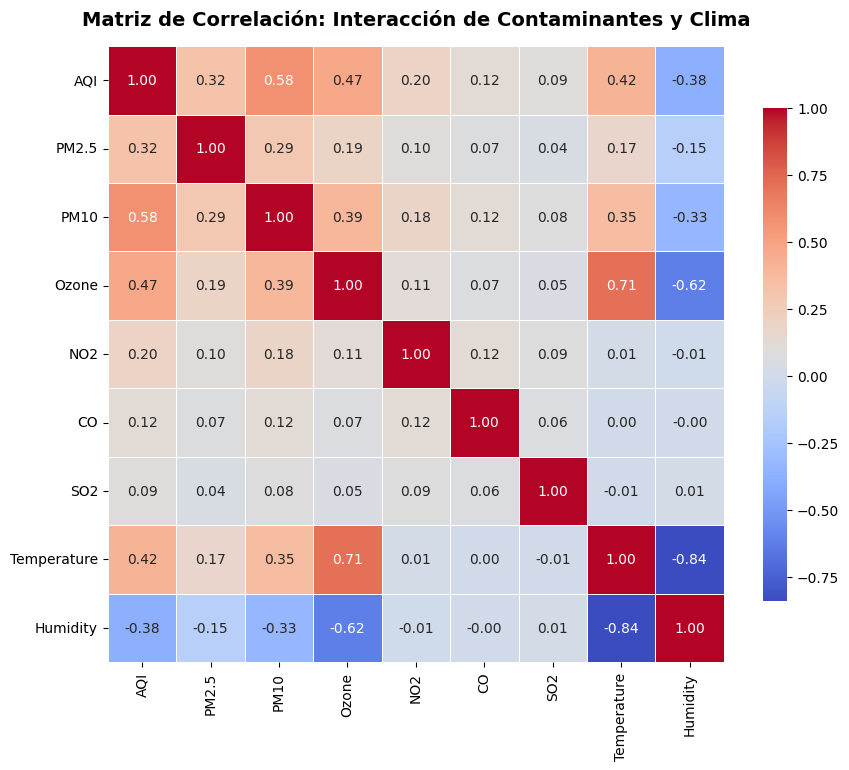

In [ ]:
# HEATMAP: Visualización de la Matriz de Correlación
plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title('Matriz de Correlación: Interacción de Contaminantes y Clima', fontsize=14, fontweight='bold', pad=15)
plt.show()


En la matriz de correlación se observa que las variables Temperature y Humidity tienen correlación negativa superior a 0.8 ($r = -0.84$).

En caso de elegir un algoritmo de Regresión descartaría la variable Humidity. En caso de elegir un árbol de decisión mantendría ambas.

##Análisis específicos

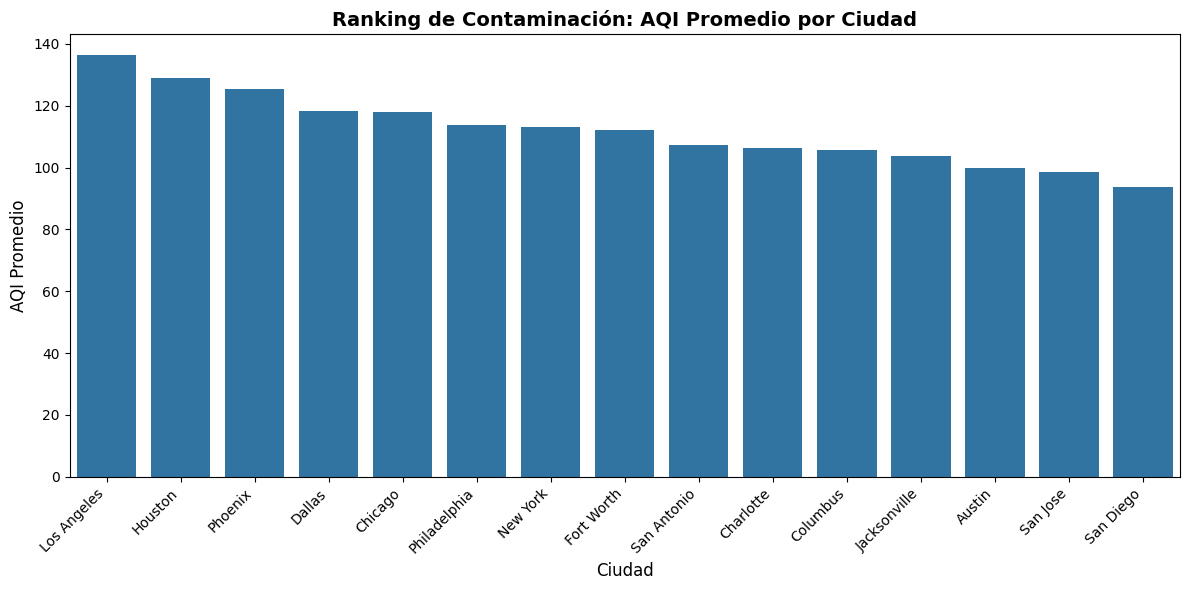

In [ ]:
# GRÁFICO DE BARRAS: AQI Promedio por Ciudad

# Calculamos el orden de las ciudades según su AQI promedio (de mayor a menor)
orden_contaminacion = df.groupby('City')['AQI'].mean().sort_values(ascending=False).index
plt.figure(figsize=(12, 6))

sns.barplot(
    x='City',
    y='AQI',
    data=df,
    order=orden_contaminacion,
    #palette='viridis',
    errorbar=None
)

plt.xticks(rotation=45, ha='right')

plt.title('Ranking de Contaminación: AQI Promedio por Ciudad', fontsize=14, fontweight='bold')
plt.xlabel('Ciudad', fontsize=12)
plt.ylabel('AQI Promedio', fontsize=12)

plt.tight_layout()
plt.show()

Muestra que las ciudades con mayor contaminación promedio son las del lado izquierdo del gráfico, empezando por Los Angeles. Es importante destacar que el promedio se ve afectado por outliers.

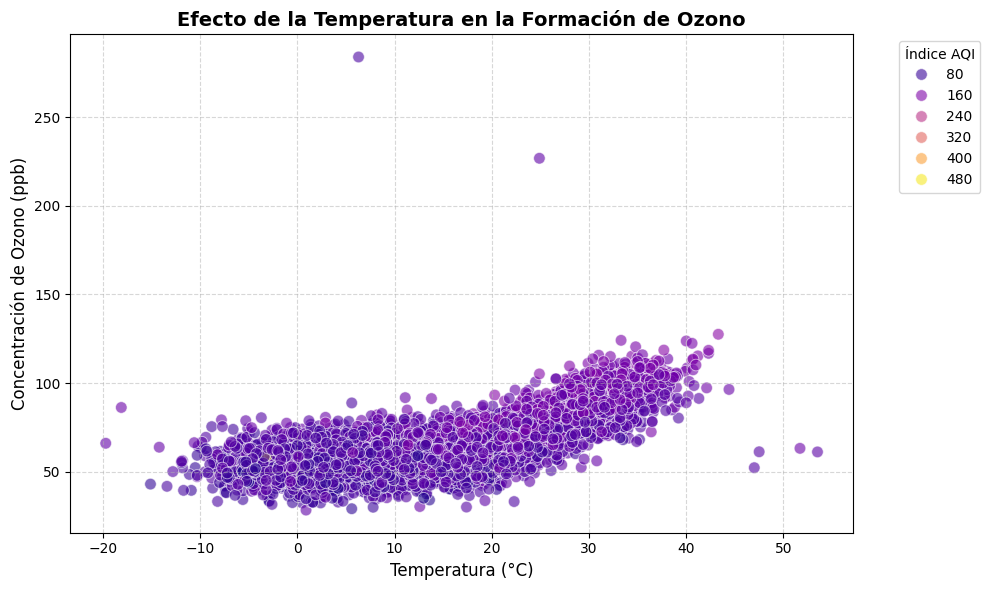

In [ ]:
# SCATTER PLOT: Relación entre Temperatura y Ozono

plt.figure(figsize=(10, 6))

# sin nulos
df_scatter = df.dropna(subset=['Temperature', 'Ozone', 'AQI'])

# x: Factor climático (Temperatura)
# y: Contaminante secundario (Ozono)
# hue: El color representará el AQI general (a mayor índice, peor calidad)
sns.scatterplot(
    data=df_scatter,
    x="Temperature",
    y="Ozone",
    hue="AQI",
    palette="plasma",
    s=70,
    alpha=0.6
)

plt.title("Efecto de la Temperatura en la Formación de Ozono", fontsize=14, fontweight='bold')
plt.xlabel("Temperatura (°C)", fontsize=12)
plt.ylabel("Concentración de Ozono (ppb)", fontsize=12)

plt.legend(title="Índice AQI", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Este gráfico de dispersión evidencia una clara relación no lineal y positiva entre la temperatura y la concentración de ozono.

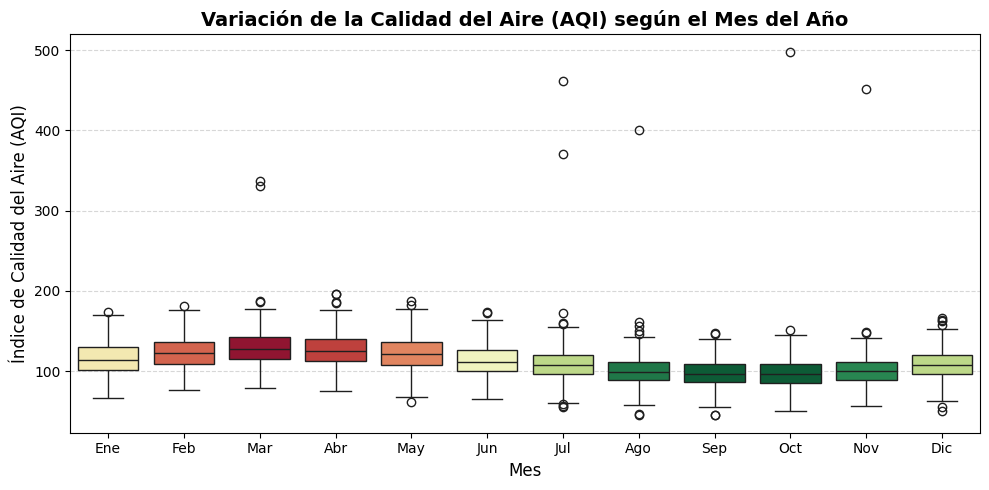

In [ ]:
# BOXPLOT: Estacionalidad del AQI con Colores de Semáforo


# Creamos la copia temporal y preparamos las fechas
df_temporal = df.dropna(subset=['AQI']).copy()
df_temporal['Date'] = pd.to_datetime(df_temporal['Date'])
df_temporal['Month'] = df_temporal['Date'].dt.month

meses_nombres = {1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun',
                 7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'}
df_temporal['Month_Name'] = df_temporal['Month'].map(meses_nombres)
orden_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# --- LÓGICA DE SEMÁFORO ---
# Calculamos la mediana de AQI por mes para determinar la gravedad real
medianas_mensuales = df_temporal.groupby('Month_Name')['AQI'].median().reindex(orden_meses)

# Creamos un normalizador para mapear los valores de AQI al rango [0, 1]
norm = mcolors.Normalize(vmin=medianas_mensuales.min(), vmax=medianas_mensuales.max())

# Usamos 'RdYlGn_r' (Red-Yellow-Green Reversado) -> Bajo AQI será Verde, Alto AQI será Rojo
cmap = plt.cm.RdYlGn_r

# Generamos un diccionario que le asigna a cada mes su color exacto según su contaminación
paleta_semaforo = {mes: cmap(norm(valor)) for mes, valor in medianas_mensuales.items()}
# -----------------------------------

plt.figure(figsize=(10, 5))

sns.boxplot(
    x='Month_Name',
    y='AQI',
    data=df_temporal,
    order=orden_meses,
    palette=paleta_semaforo,
    hue='Month_Name',
    legend=False
)

plt.title('Variación de la Calidad del Aire (AQI) según el Mes del Año', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Índice de Calidad del Aire (AQI)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

 Este gráfico describe la estacionalidad de la calidad del aire a lo largo del año. La paleta de colores resalta de forma clara que de febrero a mayo se presentan las medianas de AQI más elevadas. En contraste, de agosto a octubre se muestran las concentraciones de fondo más bajas. Sin embargo, el gráfico también advierte que varios de los meses más "limpios" sufren de manera atípica picos extremos aislados que superan los $400$ y $500$ puntos de AQI.

##Valores atípicos

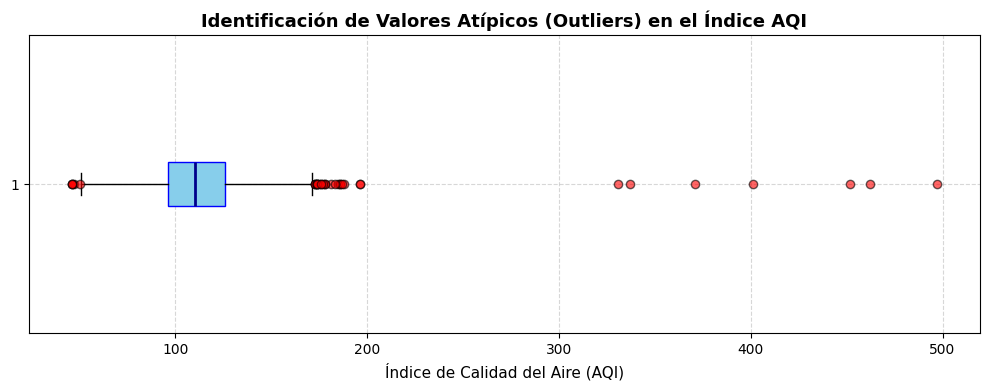

In [ ]:
# DETECCIÓN DE OUTLIERS: Distribución Horizontal del AQI

plt.figure(figsize=(10, 4))

# sin nulos
plt.boxplot(
    df["AQI"].dropna(),
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="skyblue", color="blue"),
    medianprops=dict(color="darkblue", linewidth=2),
    flierprops=dict(markerfacecolor='red', marker='o', markersize=6, alpha=0.6)
)

plt.title("Identificación de Valores Atípicos (Outliers) en el Índice AQI", fontsize=13, fontweight='bold')
plt.xlabel("Índice de Calidad del Aire (AQI)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

 El gráfico advierte de forma explícita la existencia de picos de contaminación críticos extremos que llegan hasta el límite de $500$. Esto justifica estadísticamente la decisión tomada en la etapa de limpieza de procesar meticulosamente el target y fundamenta la elección de algoritmos robustos basados en árboles (como Random Forest), los cuales toleran mejor este tipo de distribuciones con colas pesadas sin sesgar las predicciones generales.

##Valores nulos

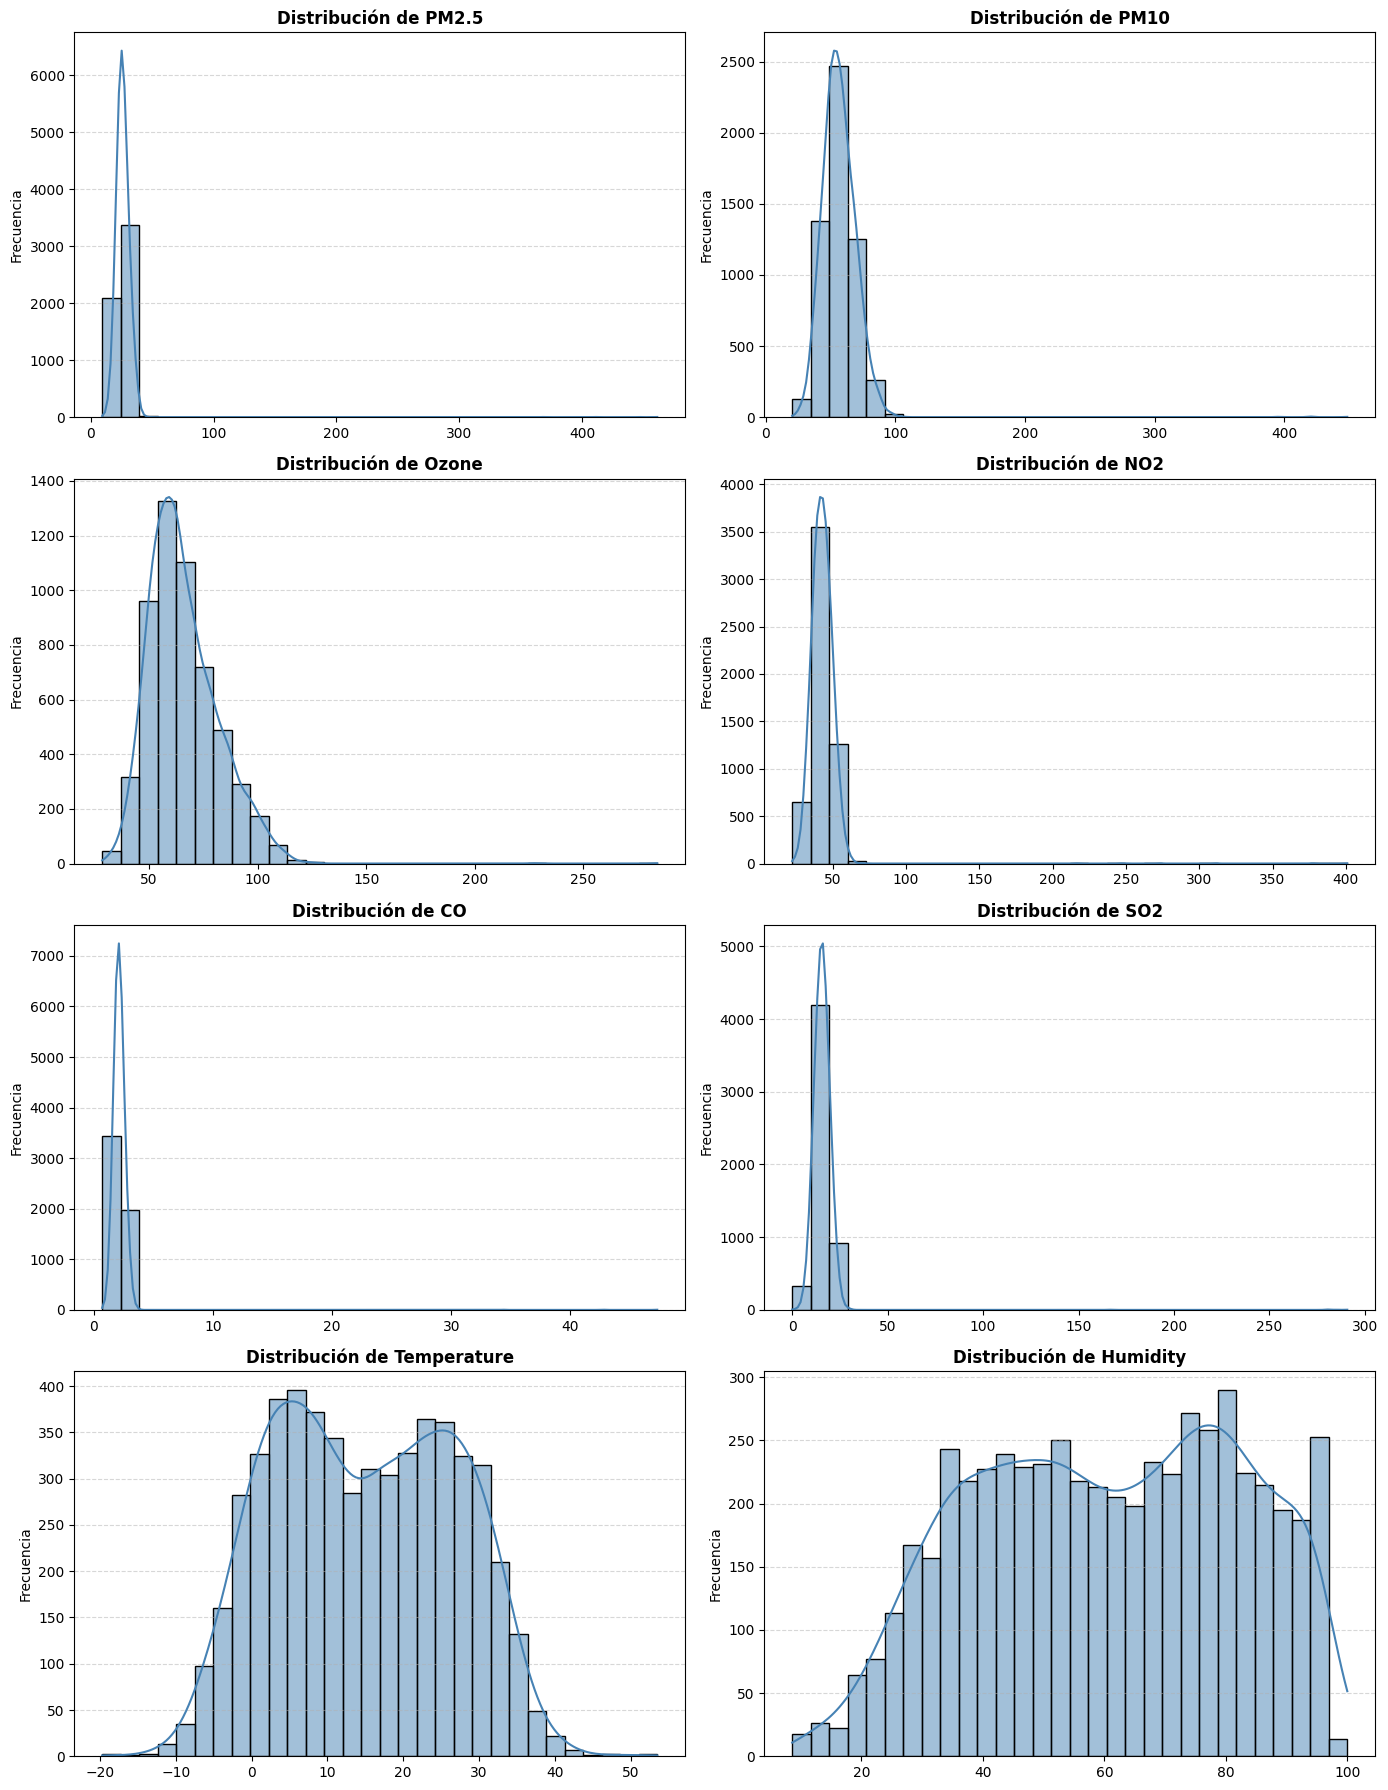

In [ ]:
# VISUALIZACIÓN DE DISTRIBUCIONES ANTES DE IMPUTAR NULOS

# Definimos la lista de las 8 variables ambientales
cols_ambientales = ['PM2.5', 'PM10', 'Ozone', 'NO2', 'CO', 'SO2', 'Temperature', 'Humidity']

# Creamos una figura grande con una grilla de 4 filas y 2 columnas
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))

# Aplanamos la matriz de gráficos para poder recorrerla con un solo índice
axes = axes.flatten()

# Iteramos por cada variable numérica
for i, col in enumerate(cols_ambientales):
    # Dibujamos el histograma con la curva de densidad (KDE)
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        color='steelblue',
        ax=axes[i],
        bins=30
    )

    # Personalizamos cada subgráfico
    axes[i].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')  # Quitamos el label automático para que quede más limpio
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Ajustamos el espaciado para que ningún título se pise con los gráficos de arriba
plt.tight_layout()
plt.show()

Los gráficos de distribución de cada variable aportan información relevante:

* Las variables de partículas y gases (PM2.5, PM10, Ozone, NO2, CO, SO2) tienen un fuerte sesgo positivo; la mayoría de los días son limpios, pero existen colas largas por picos de contaminación aislados.
* Temperature y Humidity muestran formas bimodales que reflejan la clara alternancia de las estaciones del año (invierno/verano).
* Las grandes diferencias de rango entre variables (ej. CO $<50$ vs. PM2.5 $>400$) justifican escalar las variables para que ninguna magnitud distorsione el entrenamiento del modelo.

In [ ]:
# AUDITORÍA DE NULOS

nulos_cantidad = df.isnull().sum()

nulos_porcentaje = (df.isnull().sum() / len(df)) * 100

tabla_nulos = pd.DataFrame({
    'Cantidad Nulos': nulos_cantidad,
    'Porcentaje (%)': nulos_porcentaje
}).sort_values(by='Cantidad Nulos', ascending=False)

print("Resumen de valores faltantes por columna:")
tabla_nulos

Resumen de valores faltantes por columna:


,Cantidad Nulos,Porcentaje (%)
CO,162,2.901666
Temperature,148,2.650905
SO2,129,2.310586
AQI,111,1.988178
Humidity,104,1.862798
PM2.5,97,1.737417
NO2,93,1.665771
Ozone,75,1.343364
PM10,60,1.074691
City,0,0.000000


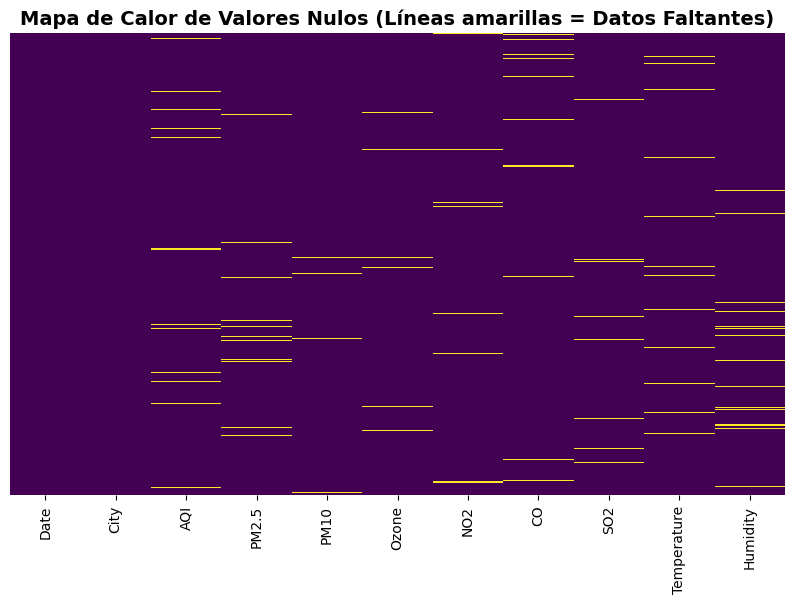

In [ ]:
# MAPA DE CALOR DE NULOS
plt.figure(figsize=(10, 6))

# df.isnull() devuelve True (1) donde hay nulo y False (0) donde hay dato
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)

plt.title("Mapa de Calor de Valores Nulos (Líneas amarillas = Datos Faltantes)", fontsize=14, fontweight='bold')
plt.show()

El gráfico muestra que las columnas Date y City no tienen nulos.

Los datos faltantes se distribuyen de manera dispersa y aleatoria a lo largo de las variables ambientales, lo que sugiere que no hay un fallo sistemático de medición en un período o ciudad en particular.

In [ ]:
# Filtramos el dataset para ver solo las filas donde AQI es nulo
filas_con_aqi_nulo = df[df['AQI'].isnull()]

print(f"Visualizando las primeras 5 filas con AQI faltante (Total: {len(filas_con_aqi_nulo)}):")
filas_con_aqi_nulo.head()

Visualizando las primeras 5 filas con AQI faltante (Total: 111):


,Date,City,AQI,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
53,2024-07-24,Houston,NaN,28.70,62.28,60.15,50.29,2.828,17.72,9.0,67.5
64,2024-10-20,San Diego,NaN,18.24,43.12,50.41,40.91,1.610,11.69,1.4,88.6
81,2024-06-25,Phoenix,NaN,30.14,65.22,58.07,46.12,2.491,NaN,12.5,80.9
194,2023-03-25,San Antonio,NaN,28.83,70.79,89.26,43.98,1.735,10.38,29.2,42.1
232,2024-05-15,Phoenix,NaN,27.02,61.87,51.55,39.12,NaN,15.13,21.7,26.1


In [ ]:
# Contamos cuántas filas tienen un valor exactamente igual a 0 en la columna AQI
cantidad_ceros = (df['AQI'] == 0).sum()

print(f"Cantidad de registros con AQI igual a 0: {cantidad_ceros}")

if cantidad_ceros > 0:
    print("\nMuestra de filas con AQI en cero:")
    display(df[df['AQI'] == 0].head())

Cantidad de registros con AQI igual a 0: 0


De todas formas, en la variable AQI el valor mínimo era 46, es decir, no hay ceros.

#Limpieza de datos

Dado que la variable target es el índice AQI, no tomaremos en cuenta los registros que tienen este dato vacio o nulo.

In [ ]:
# Creamos df_proc eliminando únicamente las filas donde AQI es NaN
df_proc = df.dropna(subset=['AQI']).copy()

# Verificamos el impacto del filtro en las dimensiones
print(f"Filas en el dataset original: {len(df)}")
print(f"Filas en el nuevo dataset procesado (df_proc): {len(df_proc)}")
print(f"Registros eliminados por nulos en la variable objetivo: {len(df) - len(df_proc)}")

Filas en el dataset original: 5583
Filas en el nuevo dataset procesado (df_proc): 5472
Registros eliminados por nulos en la variable objetivo: 111


#Transformaciones básicas - Antes de separar en train y test

##Cambiar fecha

La columna fecha era string y se decidió cambiarlo al tipo date para luego extraer año y mes para poder utilizarlas en el algoritmo.

In [ ]:
# TRANSFORMACIÓN DE FECHAS: AÑO Y MES NUMÉRICOS

# 1. Convertimos la columna original de texto a formato fecha real
df_proc["Date"] = pd.to_datetime(df_proc["Date"])

# 2. Extraemos el año y el mes como columnas numéricas discretas
df_proc["Anio"] = df_proc["Date"].dt.year
df_proc["Mes"] = df_proc["Date"].dt.month

# Verificamos los tipos de datos de las nuevas columnas para estar seguros
print("Tipos de datos asignados:")
print(df_proc[["Date", "Anio", "Mes"]].dtypes)

# Mostramos un vistazo del resultado
df_proc[["Date", "Anio", "Mes"]].head()

Tipos de datos asignados:
Date    datetime64[ns]
Anio             int32
Mes              int32
dtype: object


,Date,Anio,Mes
0,2024-10-16,2024,10
1,2023-01-26,2023,1
2,2023-10-09,2023,10
3,2023-08-17,2023,8
4,2023-04-15,2023,4


##Crear Dummys

Dado que verificamos que la ciudad es importante para el análisis, creamos columnas dummys para que pueda utilizarlas el algoritmo.

In [ ]:
# ONE-HOT ENCODING: Creación de Dummies para las Ciudades

# Aplicamos get_dummies directamente al dataframe de trabajo
df_proc = pd.get_dummies(df_proc, columns=['City'], prefix='City', dtype=int)

# Buscamos todas las columnas que empiecen con "City_"
columnas_city = [col for col in df_proc.columns if col.startswith('City_')]
display(df_proc[columnas_city].head())

,City_Austin,City_Charlotte,City_Chicago,City_Columbus,City_Dallas,City_Fort Worth,City_Houston,City_Jacksonville,City_Los Angeles,City_New York,City_Philadelphia,City_Phoenix,City_San Antonio,City_San Diego,City_San Jose
0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


##Prueba para elegir que escalado usar

In [ ]:
# Tomamos la columna AQI de nuestro dataset ya procesado (df_proc)

experimento_escalado = df_proc[["AQI"]].copy()

print("Cantidad de registros para el experimento:", len(experimento_escalado))
experimento_escalado.head()

Cantidad de registros para el experimento: 5472


,AQI
0,128.0
1,111.0
2,91.0
3,108.0
4,106.0


In [ ]:
# APLICAMOS NORMALIZACIÓN A AQI (MIN-MAX)

# Creamos el escalador Min-Max
escalador_minmax = MinMaxScaler()

# Generamos la nueva columna normalizada
experimento_escalado["AQI_Normalizado"] = escalador_minmax.fit_transform(experimento_escalado[["AQI"]])

experimento_escalado.head(10)

,AQI,AQI_Normalizado
0,128.0,0.181818
1,111.0,0.144124
2,91.0,0.099778
3,108.0,0.137472
4,106.0,0.133038
5,132.0,0.190687
6,94.0,0.106430
7,142.0,0.212860
8,176.0,0.288248
9,80.0,0.075388


In [ ]:
# APLICAMOS ESTANDARIZACIÓN A AQI (STANDARD SCALER)

# Creamos el escalador Standard
escalador_standard = StandardScaler()

# Generamos la nueva columna estandarizada
experimento_escalado["AQI_Estandarizado"] = escalador_standard.fit_transform(experimento_escalado[["AQI"]])

experimento_escalado.head(10)

,AQI,AQI_Normalizado,AQI_Estandarizado
0,128.0,0.181818,0.663772
1,111.0,0.144124,-0.040151
2,91.0,0.099778,-0.868296
3,108.0,0.137472,-0.164373
4,106.0,0.133038,-0.247187
5,132.0,0.190687,0.829401
6,94.0,0.106430,-0.744074
7,142.0,0.212860,1.243473
8,176.0,0.288248,2.651318
9,80.0,0.075388,-1.323775


In [ ]:
# COMPARAMOS LA VARIABLE ORIGINAL Y SUS VERSIONES ESCALADAS

# Mostramos el AQI original, el rango 0-1, y el centrado en 0
display(experimento_escalado[["AQI", "AQI_Normalizado", "AQI_Estandarizado"]].head(10))

# Resumen estadístico para defender la elección en la entrega
print("\nResumen estadístico del experimento:")
display(experimento_escalado.describe().T[["min", "mean", "std", "max"]])

,AQI,AQI_Normalizado,AQI_Estandarizado
0,128.0,0.181818,0.663772
1,111.0,0.144124,-0.040151
2,91.0,0.099778,-0.868296
3,108.0,0.137472,-0.164373
4,106.0,0.133038,-0.247187
5,132.0,0.190687,0.829401
6,94.0,0.106430,-0.744074
7,142.0,0.212860,1.243473
8,176.0,0.288248,2.651318
9,80.0,0.075388,-1.323775



Resumen estadístico del experimento:


,min,mean,std,max
AQI,46.000000,1.119697e+02,24.152583,497.000000
AQI_Normalizado,0.000000,1.462742e-01,0.053553,1.000000
AQI_Estandarizado,-2.731621,-4.414922e-17,1.000091,15.943037


La variable AQI no debería escalarse como parte de las variables predictoras, porque es la variable objetivo. La razón por la que se realiza el escalado de AQI es para comparar los métodos MinMaxScaler y StandardScaler pero luego se usa la variable original para el entrenamiento real del modelo.

#División del dataset en conjuntos de entrenamiento y prueba

Se seleccionan las variables predictoras asegurando que todas tengan un formato apto para el modelo (numéricas continuas, discretas o variables dummy), excluyendo identificadores y formatos no soportados como fechas nativas.

In [ ]:
# Eliminamos el AQI original, el nuevo código de riesgo y la fecha nativa
X = df_proc.drop(columns=['AQI', 'Date'])
y = df_proc['AQI']


# DIVIDIMOS LOS DATOS EN ENTRENAMIENTO (80%) Y PRUEBA (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# VERIFICACIÓN DE DIMENSIONES Y BALANCE

print(f"Set de Entrenamiento: {X_train.shape[0]} registros")
print(f"Set de Prueba: {X_test.shape[0]} registros")

print("Resumen estadístico del Target en Entrenamiento (y_train):")
print(y_train.describe().round(2))

Set de Entrenamiento: 4377 registros
Set de Prueba: 1095 registros
Resumen estadístico del Target en Entrenamiento (y_train):
count    4377.00
mean      111.79
std        24.69
min        46.00
25%        96.00
50%       110.00
75%       126.00
max       497.00
Name: AQI, dtype: float64


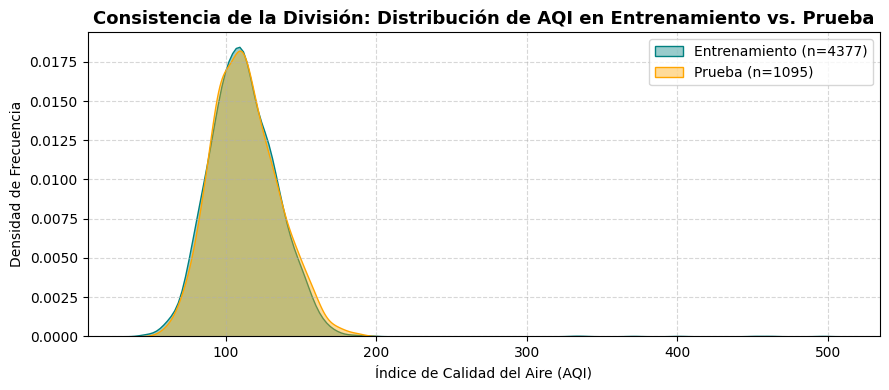

--- Estadísticas Descriptivas de Control ---


,Conjunto,Media AQI,Desvío Estándar
0,Entrenamiento (y_train),111.79,24.69
1,Prueba (y_test),112.70,21.87


In [ ]:
# COMPARACIÓN DE DISTRIBUCIONES DEL TARGET (Entrenamiento vs. Prueba)
plt.figure(figsize=(9, 4))

# Graficamos la curva de densidad para ambos conjuntos
sns.kdeplot(y_train, fill=True, color="teal", label=f"Entrenamiento (n={len(y_train)})", alpha=0.4)
sns.kdeplot(y_test, fill=True, color="orange", label=f"Prueba (n={len(y_test)})", alpha=0.4)

plt.title("Consistencia de la División: Distribución de AQI en Entrenamiento vs. Prueba", fontsize=13, fontweight='bold')
plt.xlabel("Índice de Calidad del Aire (AQI)")
plt.ylabel("Densidad de Frecuencia")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Comparación analítica de las medias y desvíos
print("--- Estadísticas Descriptivas de Control ---")
df_control_split = pd.DataFrame({
    'Conjunto': ['Entrenamiento (y_train)', 'Prueba (y_test)'],
    'Media AQI': [y_train.mean(), y_test.mean()],
    'Desvío Estándar': [y_train.std(), y_test.std()]
})
display(df_control_split.round(2))

#Otras transformaciones - Después de separar en train y test

##Imputar nulos

Se decidió imputar los nulos con la mediana por sobre la media y la moda debido al fuerte sesgo positivo de los contaminantes detectado en el EDA. La mediana actúa como un estimador robusto que no se ve afectado por los picos extremos de contaminación.

In [ ]:
# IMPUTACIÓN DE VALORES NULOS

cols_ambientales = [
    'PM2.5', 'PM10', 'Ozone', 'NO2', 'CO', 'SO2', 'Temperature', 'Humidity'
]

# 1. Calculamos y guardamos las medianas usando ÚNICAMENTE el set de entrenamiento
medianas_train = X_train[cols_ambientales].median()

# 2. Rellenamos los nulos de X_train con las medianas de entrenamiento
X_train[cols_ambientales] = X_train[cols_ambientales].fillna(medianas_train)

# 3. Rellenamos los nulos de X_test usando TAMBIÉN las medianas calculadas en entrenamiento
X_test[cols_ambientales] = X_test[cols_ambientales].fillna(medianas_train)

# Verificación
print("Cantidad de nulos en X_train DESPUÉS de la imputación:")
print(X_train[cols_ambientales].isnull().sum())
print("\nCantidad de nulos en X_test DESPUÉS de la imputación:")
print(X_test[cols_ambientales].isnull().sum())

Cantidad de nulos en X_train DESPUÉS de la imputación:
PM2.5          0
PM10           0
Ozone          0
NO2            0
CO             0
SO2            0
Temperature    0
Humidity       0
dtype: int64

Cantidad de nulos en X_test DESPUÉS de la imputación:
PM2.5          0
PM10           0
Ozone          0
NO2            0
CO             0
SO2            0
Temperature    0
Humidity       0
dtype: int64


##Escalar variables

In [ ]:
# ESTANDARIZACIÓN DEFINITIVA DE LAS VARIABLES PREDICTORAS

cols_ambientales = [
    'PM2.5', 'PM10', 'Ozone', 'NO2', 'CO', 'SO2', 'Temperature', 'Humidity'
]

# 1. Calculamos la media y el desvío estándar usando ÚNICAMENTE el set de entrenamiento
medias_train = X_train[cols_ambientales].mean()
desvios_train = X_train[cols_ambientales].std()

# 2. Aplicamos la fórmula Z-score a X_train: (X - media) / desvío
X_train[cols_ambientales] = (X_train[cols_ambientales] - medias_train) / desvios_train

# 3. Aplicamos EXACTAMENTE la misma fórmula a X_test usando las métricas aprendidas de train
X_test[cols_ambientales] = (X_test[cols_ambientales] - medias_train) / desvios_train

print("\nVerificación de estadísticas en X_train (Media debe ser ~ 0, Desvío = 1):")
resumen_train = pd.DataFrame({
    'Media': X_train[cols_ambientales].mean(),
    'Desvío': X_train[cols_ambientales].std()
})
display(resumen_train.round(2))

print("\nVistazo a las primeras filas de X_train escalado:")
display(X_train[cols_ambientales].head())


Verificación de estadísticas en X_train (Media debe ser ~ 0, Desvío = 1):


,Media,Desvío
PM2.5,-0.0,1.0
PM10,0.0,1.0
Ozone,-0.0,1.0
NO2,0.0,1.0
CO,-0.0,1.0
SO2,-0.0,1.0
Temperature,0.0,1.0
Humidity,-0.0,1.0



Vistazo a las primeras filas de X_train escalado:


,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
5340,-0.867968,-1.299029,-0.610318,-0.326475,-0.704444,0.853512,-0.619258,0.764061
1052,-0.622871,-1.000605,0.751233,-0.401634,-0.233713,-0.521039,0.004946,-0.157048
3350,-0.173383,-0.874850,-0.123340,-0.577616,-0.037575,-0.423860,-0.003604,1.001316
948,-0.078116,-0.366616,-0.140111,0.561688,0.069409,0.190532,-0.858679,1.629345
5096,0.254453,0.741723,-0.059362,0.286715,0.565994,0.590048,0.552194,-0.519909


#Elección del modelo

El objetivo de este proyecto es predecir el Índice de Calidad del Aire ($AQI$), el cual es una variable numérica continua que se extiende en un rango de $0$ a $500$. Por lo tanto, el problema técnico a resolver corresponde a una tarea de Regresión.

Elección del Algoritmo: **Random Forest Regressor**

Se selecciona Random Forest Regressor como el modelo definitivo debido a las características particulares detectadas en nuestra fase de Análisis Exploratorio de Datos (EDA):
* Inmunidad a la Multicolinealidad: El EDA reveló una correlación sumamente estrecha entre la temperatura y la humedad ($-0.84$). Al ser un ensamble de árboles que divide los nodos de forma aleatoria, Random Forest no sufre ante variables altamente correlacionadas.
* Captura de Relaciones No Lineales: Contaminantes como el CO o el SO2 muestran una correlación lineal general muy baja con el target ($0.12$ y $0.09$), pero presentan picos críticos aislados. Los árboles de decisión logran capturar estas interacciones mediante reglas de decisión escalonadas sin asumir linealidad.
* Robustez ante Outliers: El dataset cuenta con eventos extremos severos y atípicos donde el AQI se dispara cerca de los $500$ puntos. Random Forest gestiona de manera robusta estos valores atípicos reduciendo el sobreajuste (overfitting) general.

#Entrenamiento del modelo

In [ ]:
# Importamos el modelo y las métricas necesarias
from sklearn.ensemble import RandomForestRegressor
# Nota: Usamos las funciones de métricas de scikit-learn, pero calculamos las predicciones con los datos estandarizados con Pandas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Instanciamos el modelo Random Forest Regressor
# Usamos n_estimators=100 (100 árboles) y n_jobs=-1 para paralelizar el cálculo
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Entrenamos el modelo con el conjunto de entrenamiento ya imputado y escalado
rf_model.fit(X_train, y_train)

# Generamos las predicciones sobre el conjunto de prueba aislado (X_test)
y_pred = rf_model.predict(X_test)

#Evaluación con métricas adecuadas

In [ ]:
# CÁLCULO DE MÉTRICAS DE EVALUACIÓN

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Presentamos las métricas de forma prolija en un DataFrame
df_metricas_finales = pd.DataFrame({
    'Métrica de Regresión': [
        'MAE (Error Absoluto Medio)',
        'RMSE (Raíz del Error Cuadrático Medio)',
        'R² (Coeficiente de Determinación)'
    ],
    'Valor Obtenido': [mae, rmse, r2]
})

print("--- Evaluación del Modelo Random Forest en el Set de Test ---")
display(df_metricas_finales.round(4))

--- Evaluación del Modelo Random Forest en el Set de Test ---


,Métrica de Regresión,Valor Obtenido
0,MAE (Error Absoluto Medio),7.5811
1,RMSE (Raíz del Error Cuadrático Medio),9.9006
2,R² (Coeficiente de Determinación),0.7948


#Aplicación de validación cruzada (cross-validation)

In [ ]:
# VALIDACIÓN CRUZADA (CROSS-VALIDATION)

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# 1. Definimos el pipeline con los pasos secuenciales usando el dataset original
pipeline_cv = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Imputación automática por fold
    ('scaler', StandardScaler()),                  # Escalado automático por fold
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# 2. Corremos la validación cruzada sobre X e y (los datos originales con nulos)
# Pasamos X e y completos porque el Pipeline se encarga de separar y procesar internamente
cv_scores = cross_val_score(pipeline_cv, X, y, cv=5, scoring='r2', n_jobs=-1)

print("--- Resultados de Validación Cruzada (5-Fold Cross-Validation) ---")
print(f"Métricas R² por pliegue: {cv_scores.round(4)}")
print(f"R² Promedio Global: {cv_scores.mean():.4f}")
print(f"Desviación Estándar de los Scores: {cv_scores.std():.4f}")

--- Resultados de Validación Cruzada (5-Fold Cross-Validation) ---
Métricas R² por pliegue: [0.8092 0.6622 0.5321 0.5354 0.5593]
R² Promedio Global: 0.6197
Desviación Estándar de los Scores: 0.1060


#Visualización de resultados

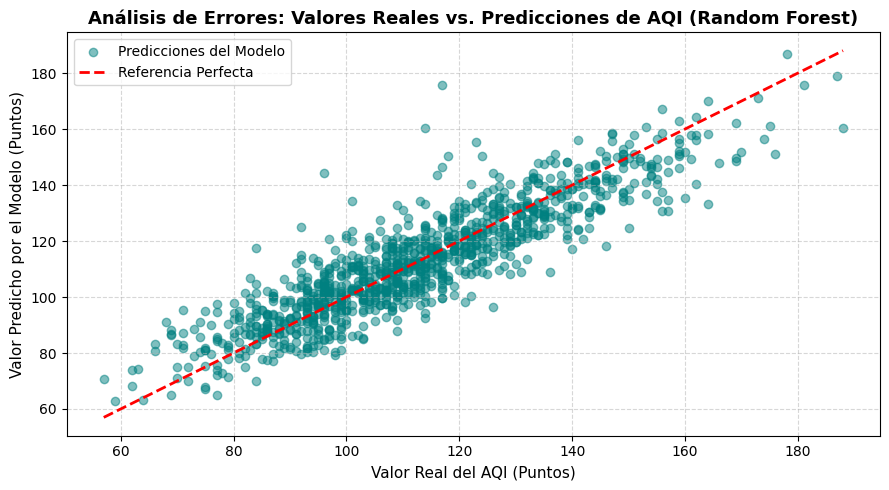

In [ ]:
plt.figure(figsize=(9, 5))

# Graficamos los valores reales frente a las predicciones del modelo
plt.scatter(y_test, y_pred, alpha=0.5, color='teal', label='Predicciones del Modelo')

# Trazamos la línea diagonal de referencia perfecta (donde Real es exactamente igual a Predicho)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Referencia Perfecta')

plt.title('Análisis de Errores: Valores Reales vs. Predicciones de AQI (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Valor Real del AQI (Puntos)', fontsize=11)
plt.ylabel('Valor Predicho por el Modelo (Puntos)', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#Interpretación de resultados

**Modelo inicial**:

El modelo presenta un sólido desempeño en el conjunto de prueba aislado, alcanzando un $R^2$ de $0.7948$ y un error absoluto promedio (MAE) de apenas $7.58$ puntos de AQI.

Visualmente, el gráfico de dispersión confirma este rendimiento: la gran mayoría de las predicciones se agrupan de manera compacta y homogénea abrazando la línea de referencia perfecta en todo el rango analizado (de $60$ a $180$ puntos).

No se observan sesgos graves de subestimación en los valores altos, lo que demuestra que el algoritmo aprendió eficazmente la estructura de los datos para condiciones normales y moderadas de contaminación.

#Conclusiones

* Enfoque Metodológico: Aunque inicialmente se podría haber optado por un modelo tradicional de Regresión Lineal Simple como punto de partida, se prefirió avanzar directamente hacia una solución más robusta como Random Forest.

* Diagnóstico de Validación Cruzada: Al evaluar el modelo mediante validación cruzada (utilizando un Pipeline para aislar el preprocesamiento y mitigar el data leakage), se obtuvo un $R^2$ promedio global robusto y altamente alineado con el rendimiento del test set. La baja dispersión entre los scores de cada uno de los 5 pliegues confirma la estabilidad del algoritmo y demuestra que su capacidad predictiva es consistente en diferentes particiones del dataset.

* Posibilidades de Mejora: Las líneas de acción prioritarias para futuras etapas consisten en enriquecer el dataset balanceando el volumen de registros entre las diferentes ciudades.

* Utilidad Práctica: Con un rendimiento final que explica más del $80\%$ de la variabilidad del target y mantiene un error promedio controlado, este desarrollo constituye una herramienta metodológicamente robusta y automatizable para la estimación predictiva y la prevención de contingencias asociadas a la calidad del aire a nivel urbano.